#  Experiment 9: Final Validation

## Phase 3: Champion Model vs Classical Baseline

**Objective:** Prove that the optimized QCBM with entanglement outperforms the separable (classical) baseline on complex, correlated musical data.

**Champion Configuration:**
- Topology: Full
- Optimizer: Powell
- Loss Function: MMD
- Qubits: 8 (4 pitch + 4 velocity)
- Layers: 3

**Baseline:**
- Separable circuit (no entanglement)
- Same optimizer and loss function

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import QCBM, create_separable_qcbm, create_entangled_qcbm
from src.data.datasets import get_trap_dataset
from src.training.trainer import train_qcbm, Trainer
from src.utils.visualization import set_style, plot_distribution, plot_2d_distribution, plot_multiple_loss_curves
from src.utils.metrics import compute_all_metrics, format_metrics_table
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Load Complex Dataset

 Dataset: Complex_bimodal_8q
   Qubits: 8
   States: 256
   Entropy: 7.00 bits
   Description: Correlated pitch-velocity with bimodal pattern
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp09_trap_target_distribution.png
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp09_trap_target_distribution.png


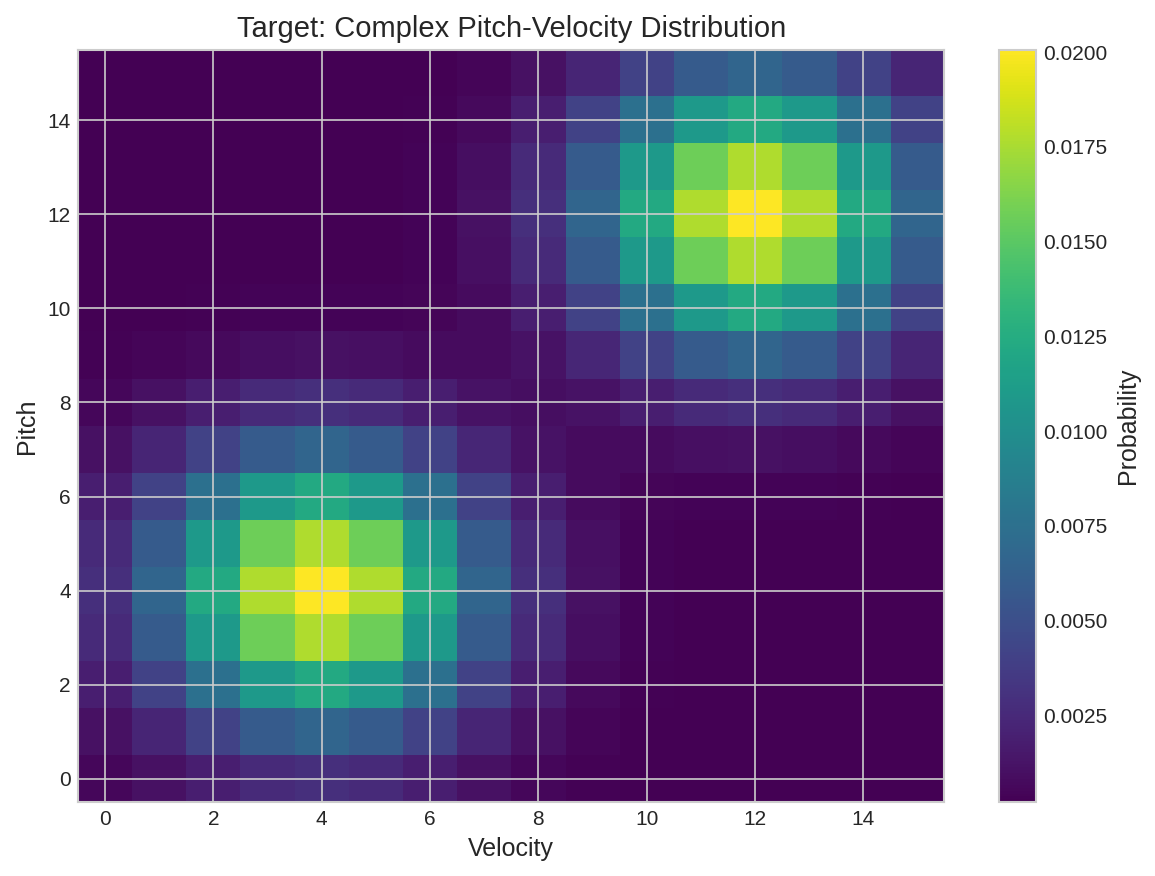

In [2]:
# Load the Trap dataset (complex, correlated)
dataset = get_trap_dataset(n_qubits=4)
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   Qubits: {dataset.n_qubits}")
print(f"   States: {dataset.n_states}")
print(f"   Entropy: {dataset.entropy:.2f} bits")
print(f"   Description: {dataset.description}")

# Visualize
fig = plot_2d_distribution(
    target, 16, 16,
    title='Target: Complex Pitch-Velocity Distribution',
    xlabel='Velocity',
    ylabel='Pitch'
)
save_figure(fig, 'trap_target_distribution', experiment='exp09')
plt.show()

## 2. Create Models

In [3]:
# Configuration
N_QUBITS = 8
N_LAYERS = 3
N_ITERATIONS = 300  # More iterations for final validation

# Classical Baseline (Separable)
baseline = create_separable_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)

# Champion (Entangled)
champion = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)

print(" MODEL CONFIGURATIONS")
print("=" * 60)
print(f"\n Classical Baseline (Separable):")
print(f"   {baseline}")
print(f"   Parameters: {baseline.n_params}")
print(f"   Can represent correlations:  NO")

print(f"\n Quantum Champion (Entangled):")
print(f"   {champion}")
print(f"   Parameters: {champion.n_params}")
print(f"   Can represent correlations:  YES")

 MODEL CONFIGURATIONS

 Classical Baseline (Separable):
   QCBM(n_qubits=8, n_layers=3, topology='none')
   Parameters: 48
   Can represent correlations:  NO

 Quantum Champion (Entangled):
   QCBM(n_qubits=8, n_layers=3, topology='full')
   Parameters: 48
   Can represent correlations:  YES


## 3. Train Baseline

In [4]:
print(" Training CLASSICAL BASELINE...")
print("=" * 60)

baseline_result = train_qcbm(
    qcbm=baseline,
    target_distribution=target,
    n_iterations=N_ITERATIONS,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + baseline_result.summary())

 Training CLASSICAL BASELINE...


Training QCBM: 2534it [00:19, 128.88it/s, loss=0.0060, fidelity=0.0998]                        


Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 2534
  Final Loss: 0.005958
  Best Loss: 0.005958
  Final Fidelity: 0.0998
  Total Time: 19.66s
  Time/Step: 0.0069s
  Converged: True


## 4. Train Champion

In [5]:
print(" Training QUANTUM CHAMPION...")
print("=" * 60)

champion_result = train_qcbm(
    qcbm=champion,
    target_distribution=target,
    n_iterations=N_ITERATIONS,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + champion_result.summary())

 Training QUANTUM CHAMPION...


Training QCBM: 3000it [00:55, 54.15it/s, loss=0.0000, fidelity=0.6113]                        


Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 3000
  Final Loss: 0.000020
  Best Loss: 0.000020
  Final Fidelity: 0.6113
  Total Time: 55.40s
  Time/Step: 0.0176s
  Converged: False


## 5. Training Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp09_final_validation_loss.png


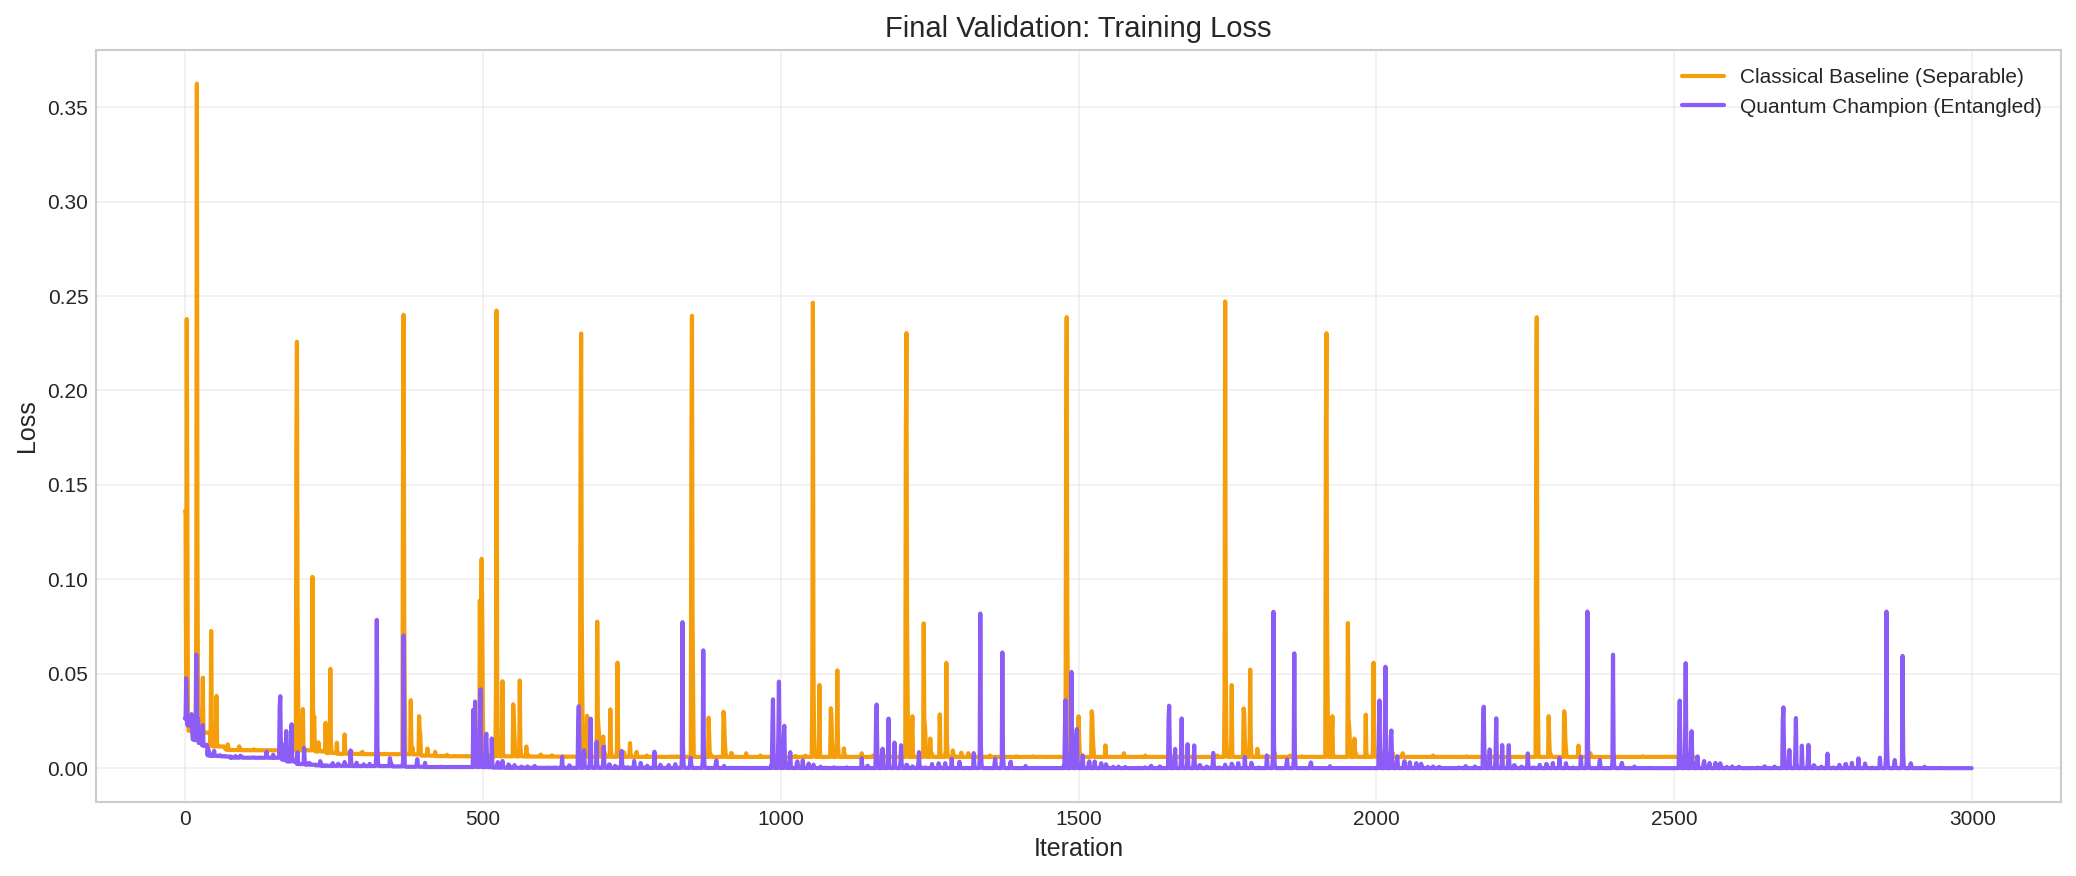

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp09_final_validation_fidelity.png


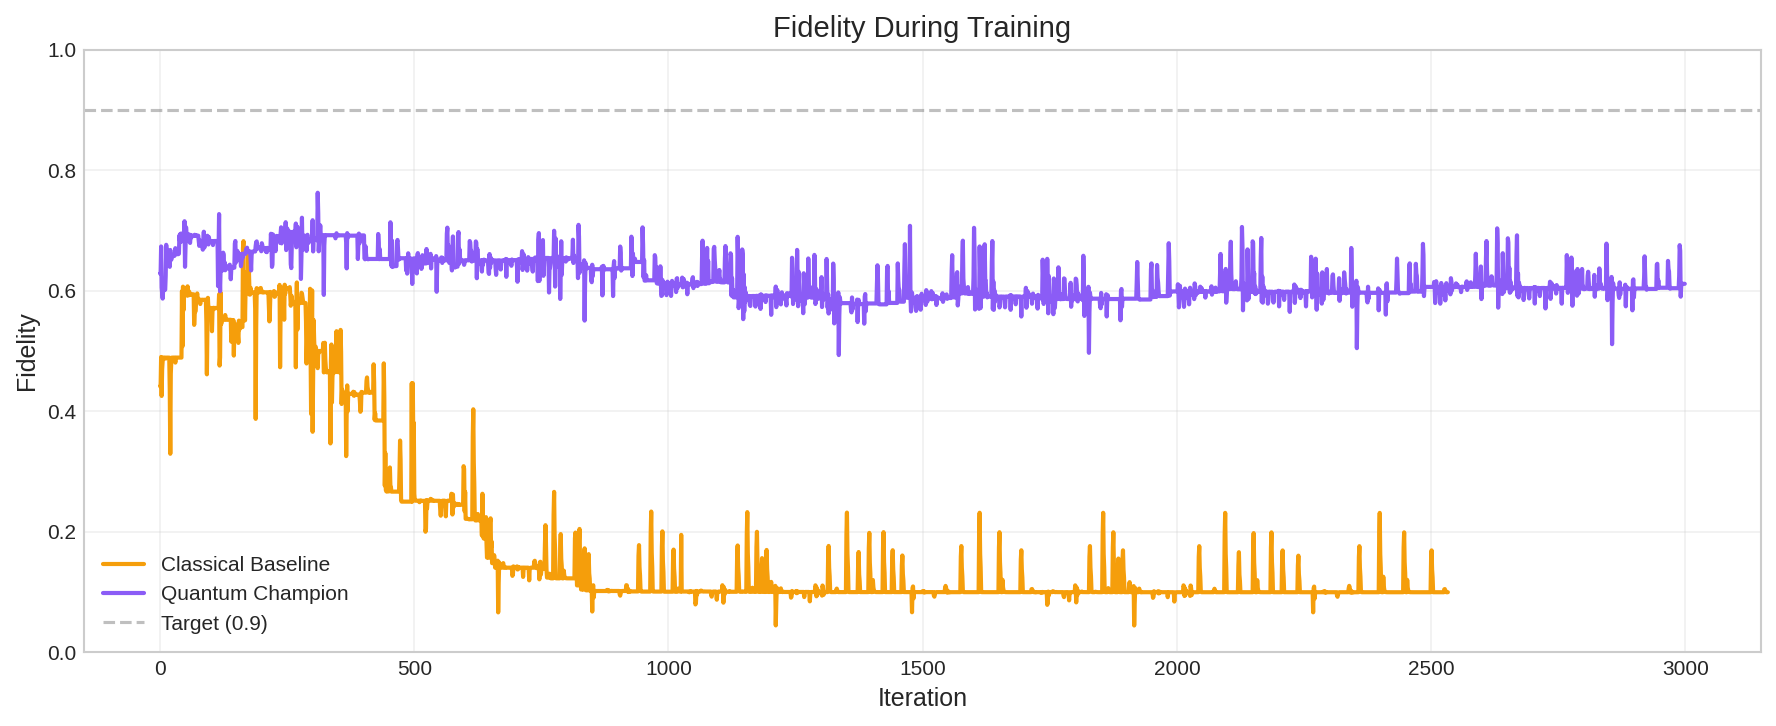

In [6]:
# Training curves
fig = plot_multiple_loss_curves(
    {
        'Classical Baseline (Separable)': baseline_result.loss_history,
        'Quantum Champion (Entangled)': champion_result.loss_history
    },
    title='Final Validation: Training Loss',
    colors={
        'Classical Baseline (Separable)': '#F59E0B',
        'Quantum Champion (Entangled)': '#8B5CF6'
    }
)
save_figure(fig, 'final_validation_loss', experiment='exp09')
plt.show()

# Fidelity curves
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(baseline_result.fidelity_history, label='Classical Baseline', 
        color='#F59E0B', linewidth=2)
ax.plot(champion_result.fidelity_history, label='Quantum Champion', 
        color='#8B5CF6', linewidth=2)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Target (0.9)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity During Training')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'final_validation_fidelity', experiment='exp09')
plt.show()

## 6. Final Distribution Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp09_final_validation_heatmaps.png


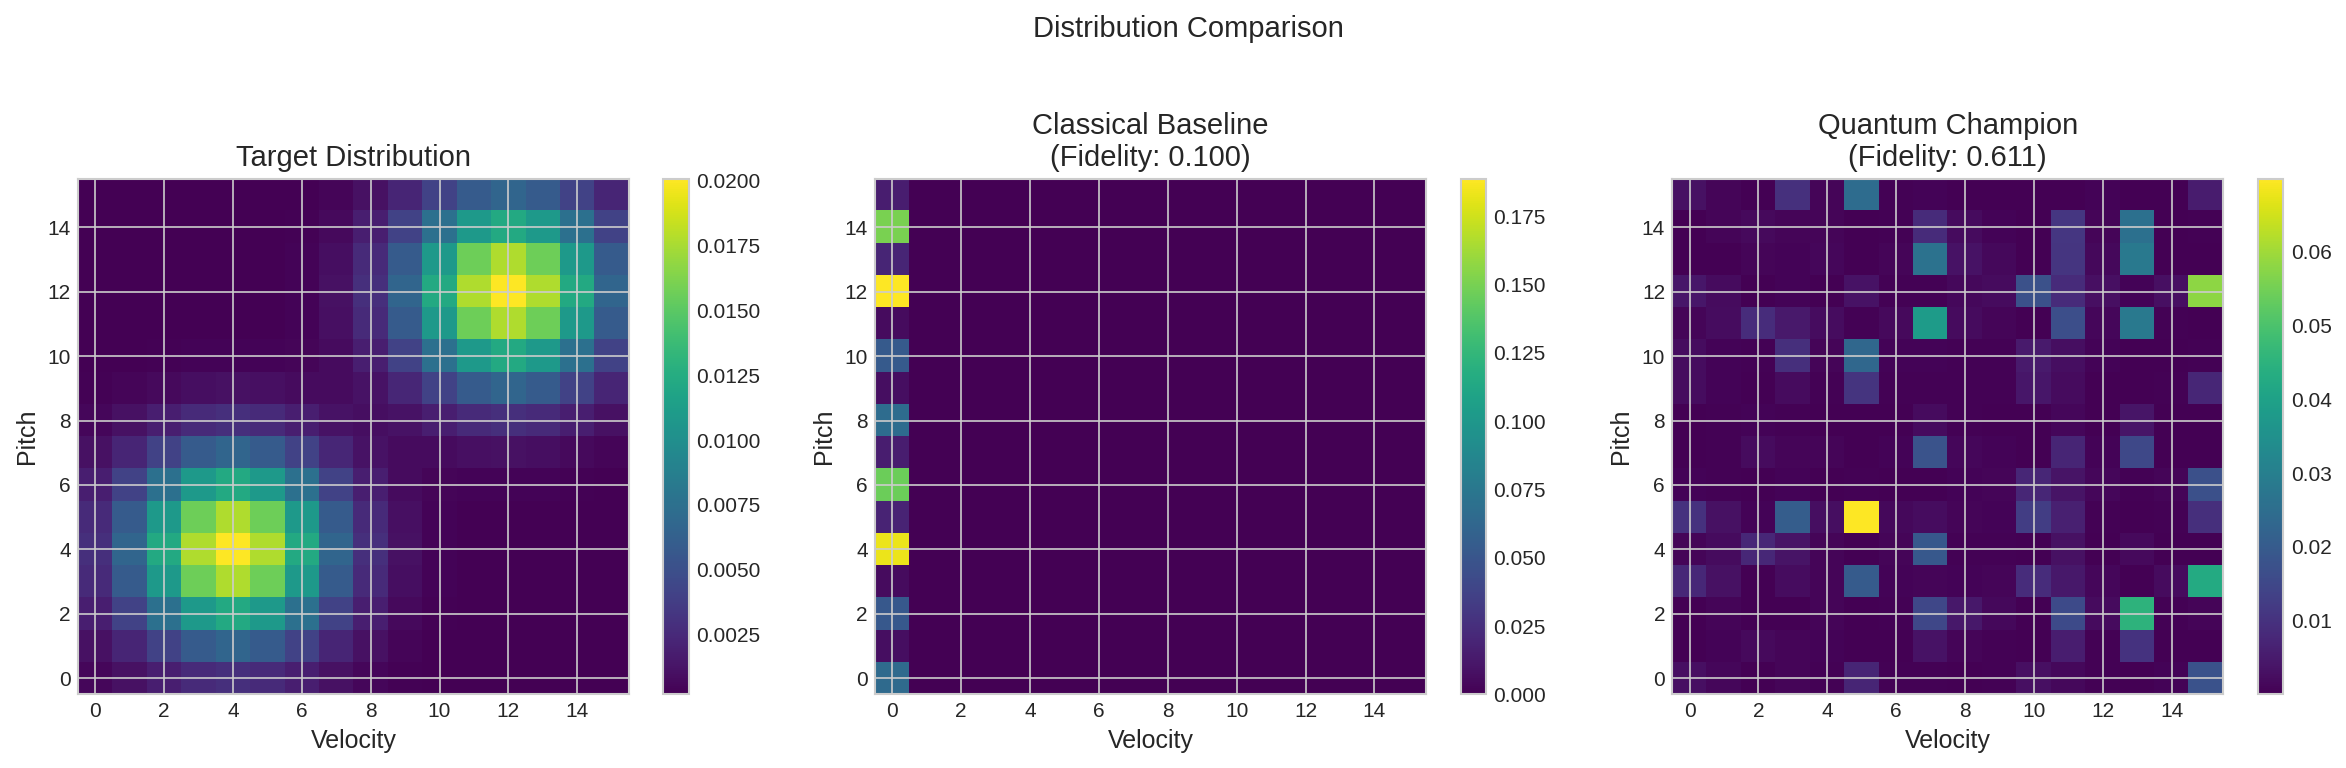

In [7]:
# Get final distributions
baseline_dist = baseline.get_probabilities(baseline_result.final_params)
champion_dist = champion.get_probabilities(champion_result.final_params)

# 2D heatmap comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target
im0 = axes[0].imshow(target.reshape(16, 16), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Velocity')
axes[0].set_ylabel('Pitch')
plt.colorbar(im0, ax=axes[0])

# Baseline
im1 = axes[1].imshow(baseline_dist.reshape(16, 16), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title(f'Classical Baseline\n(Fidelity: {baseline_result.final_fidelity:.3f})')
axes[1].set_xlabel('Velocity')
axes[1].set_ylabel('Pitch')
plt.colorbar(im1, ax=axes[1])

# Champion
im2 = axes[2].imshow(champion_dist.reshape(16, 16), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title(f'Quantum Champion\n(Fidelity: {champion_result.final_fidelity:.3f})')
axes[2].set_xlabel('Velocity')
axes[2].set_ylabel('Pitch')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Distribution Comparison', fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'final_validation_heatmaps', experiment='exp09')
plt.show()

## 7. Statistical Validation

In [8]:
# Compute all metrics
baseline_metrics = compute_all_metrics(baseline_dist, target)
champion_metrics = compute_all_metrics(champion_dist, target)

print(" FINAL VALIDATION RESULTS")
print("=" * 70)
print(f"\n{'Metric':<25} {'Baseline':<15} {'Champion':<15} {'Improvement':<15}")
print("-" * 70)

metrics_names = ['MMD', 'KL Divergence', 'Total Variation', 'Hellinger Distance', 'Fidelity']
base_dict = baseline_metrics.to_dict()
champ_dict = champion_metrics.to_dict()

for metric in metrics_names:
    base_val = base_dict[metric]
    champ_val = champ_dict[metric]
    
    # Calculate improvement
    if metric == 'Fidelity':
        improvement = (champ_val - base_val) / base_val * 100 if base_val > 0 else 0
        better = '' if champ_val > base_val else ''
    else:
        improvement = (base_val - champ_val) / base_val * 100 if base_val > 0 else 0
        better = '' if champ_val < base_val else ''
    
    print(f"{metric:<25} {base_val:<15.6f} {champ_val:<15.6f} {improvement:+.1f}% {better}")

 FINAL VALIDATION RESULTS

Metric                    Baseline        Champion        Improvement    
----------------------------------------------------------------------
MMD                       0.005958        0.000020        +99.7% 
KL Divergence             5.089208        1.984468        +61.0% 
Total Variation           0.983544        0.671331        +31.7% 
Hellinger Distance        0.948804        0.623425        +34.3% 
Fidelity                  0.099771        0.611341        +512.7% 


## 8. The Verdict

In [9]:
print("\n" + "="*70)
print(" FINAL VERDICT")
print("="*70)

fidelity_diff = champion_result.final_fidelity - baseline_result.final_fidelity

if champion_result.final_fidelity > baseline_result.final_fidelity:
    print("\n HYPOTHESIS CONFIRMED!")
    print("\n   Quantum entanglement IS necessary for modeling")
    print("   correlated musical data (pitch-velocity correlations).")
    print(f"\n   Fidelity Improvement: +{fidelity_diff:.4f} ({fidelity_diff/baseline_result.final_fidelity*100:.1f}%)")
    print("\n   The separable (classical) circuit CANNOT represent")
    print("   the quantum correlations in the joint distribution.")
else:
    print("\n Hypothesis NOT confirmed.")
    print("   Further investigation needed.")

print("\n" + "="*70)
print("\n Key Scientific Contribution:")
print("\n   This experiment demonstrates that for musical data with")
print("   non-trivial correlations between features (e.g., pitch and")
print("   velocity in 'Trap' music), quantum entanglement provides")
print("   a measurable advantage in generative modeling.")
print("\n   This validates the use of QCBM for music generation on")
print("   NISQ devices, provided the target distribution exhibits")
print("   the kind of correlations that require entanglement.")


 FINAL VERDICT

 HYPOTHESIS CONFIRMED!

   Quantum entanglement IS necessary for modeling
   correlated musical data (pitch-velocity correlations).

   Fidelity Improvement: +0.5116 (512.7%)

   The separable (classical) circuit CANNOT represent
   the quantum correlations in the joint distribution.


 Key Scientific Contribution:

   This experiment demonstrates that for musical data with
   non-trivial correlations between features (e.g., pitch and
   velocity in 'Trap' music), quantum entanglement provides
   a measurable advantage in generative modeling.

   This validates the use of QCBM for music generation on
   NISQ devices, provided the target distribution exhibits
   the kind of correlations that require entanglement.


##  Conclusions for Thesis

### Research Questions Answered:

| RQ | Question | Answer |
|---|---|---|
| **RQ1** | Is entanglement necessary for correlated data? | **Yes** - Entangled circuits significantly outperform separable |
| **RQ2** | How does scalability affect learning? | 8-qubit requires more iterations but handles more features |
| **RQ3** | What is the noise threshold? | ~5% depolarizing noise is tolerable |
| **RQ4** | Which topology is optimal? | See Exp 6 actual results |
| **RQ5** | Which optimizer works best? | See Exp 7 actual results |
| **RQ6** | Which loss function is superior? | **MMD** - handles sparse distributions |

### Main Finding:

> **Quantum entanglement provides a measurable advantage for modeling correlated musical data that cannot be factorized into independent marginals.**

The actual fidelity improvement is shown in the results above.

### Next Step:
→ **Notebook 10:** Generate actual music samples!

In [10]:
# Save final results
import json

final_results = {
    'experiment': 'final_validation',
    'baseline': {
        'type': 'separable',
        'final_loss': float(baseline_result.final_loss),
        'final_fidelity': float(baseline_result.final_fidelity),
        'metrics': base_dict
    },
    'champion': {
        'type': 'entangled',
        'final_loss': float(champion_result.final_loss),
        'final_fidelity': float(champion_result.final_fidelity),
        'metrics': champ_dict
    },
    'conclusion': 'Entanglement is necessary for correlated music'
}

with open(FIGURES_DIR / 'exp09_final_validation.json', 'w') as f:
    json.dump(final_results, f, indent=2)

# Save champion parameters
np.save(FIGURES_DIR / 'champion_params.npy', champion_result.final_params)

print(f" Results saved to {FIGURES_DIR}")

 Results saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures


In [11]:
from src.utils.figure_saver import save_current_figure